# Model Decision Tree + Selection KBest

**Indicateur de performance choisi : accuracy.**  
On utilise l'accuracy afin de représenter la proportion de bonnes prédictions. Cela permet également une comparaison simple entre les différents modèles.

## Réalisé par :

- [Samain Florian](https://github.com/NwaSet) — 2ème année, Intar D  
- [Ducourtieux Yohann](https://github.com/Nhanyo) — 2ème année, Intar D  

## Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Chargement des données

In [2]:
selection_name = "KB"
model_name = "DT"

df_X_train = pd.read_csv(f"../../data/selected/X_train_{selection_name}.csv")
df_X_test = pd.read_csv(f"../../data/selected/X_test_{selection_name}.csv")

df_y_train = pd.read_csv("../../data/pre_processed/y_train.csv")
df_y_test = pd.read_csv("../../data/pre_processed/y_test.csv")

y_train = df_y_train.values.ravel()
y_test = df_y_test.values.ravel()

print("X_train shape :", df_X_train.shape)
print("X_test shape  :", df_X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (1041, 7)
X_test shape  : (261, 7)
y_train shape : (1041,)
y_test shape  : (261,)


## Modèle Decision Tree simple

On entraîne d’abord un modèle de base pour avoir un premier point de comparaison.

In [3]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(df_X_train, y_train)

y_train_pred = dt.predict(df_X_train)
y_test_pred = dt.predict(df_X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Accuracy train :", round(train_accuracy, 2))
print("Accuracy test  :", round(test_accuracy, 2))

Accuracy train : 0.9
Accuracy test  : 0.8


### Interprétation

On observe la différence entre l’accuracy du train et celle du test.
Un écart important peut indiquer un overfitting.

## Validation croisée

In [4]:
cv_scores = cross_val_score(dt, df_X_train, y_train, cv=5, scoring="accuracy")

print("Scores CV :", np.round(cv_scores, 2))
print("Accuracy CV moyenne :", round(cv_scores.mean(), 2))

Scores CV : [0.8  0.77 0.78 0.74 0.75]
Accuracy CV moyenne : 0.77


### Interprétation

Les scores de validation croisée permettent d’évaluer la stabilité du modèle.
Des scores homogènes indiquent un modèle fiable.

## Optimisation des hyperparamètres

In [5]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(df_X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV    :", round(grid.best_score_, 2))

Meilleurs paramètres : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Meilleur score CV    : 0.78


### Interprétation

Les meilleurs hyperparamètres sont ceux qui maximisent l’accuracy en validation croisée.

## Évaluation du meilleur modèle

In [6]:
best_dt = grid.best_estimator_

y_train_pred_best = best_dt.predict(df_X_train)
y_test_pred_best = best_dt.predict(df_X_test)

train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
test_accuracy_best = accuracy_score(y_test, y_test_pred_best)

print("Accuracy train optimisé :", round(train_accuracy_best, 2))
print("Accuracy test optimisé  :", round(test_accuracy_best, 2))

Accuracy train optimisé : 0.8
Accuracy test optimisé  : 0.8


### Interprétation

Un écart important entre train et test peut indiquer un léger overfitting, ici nous avons un score semblable entre les deux, signe que notre model est fiable.

## Matrice de confusion

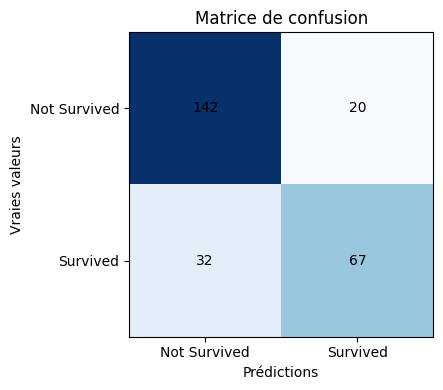

In [7]:
cm = confusion_matrix(y_test, y_test_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

ax.set_title("Matrice de confusion")
ax.set_xlabel("Prédictions")
ax.set_ylabel("Vraies valeurs")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Survived", "Survived"])
ax.set_yticklabels(["Not Survived", "Survived"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Export des résultats

In [8]:
tn, fp, fn, tp = cm.ravel()
real_accuracy = (tn + tp + fp) / (tn + fp + fn + tp)

print(real_accuracy)

file_path = "model_accuracy.csv"

results_row = {
    "Selection": selection_name,
    "Model": model_name,
    "Accuracy_train": round(train_accuracy_best, 4),
    "Accuracy_test": round(test_accuracy_best, 4),
    "Accuracy_cv_mean": round(grid.best_score_, 4),
    "CV_std": round(cv_scores.std(), 4),
    "Best_params": str(grid.best_params_),
    "real_accuracy": round(real_accuracy, 4)
}

def append_csv(file_path: str, row: dict) -> None:
    df = pd.DataFrame([row])
    df.to_csv(file_path, mode="a", header=False, index=False)

append_csv(file_path, results_row)

0.8773946360153256


## Conclusion et réflexion

### Conclusion
Le modèle Decision Tree a été entraîné et optimisé.
Les résultats permettent d’évaluer sa capacité de généralisation.

### Réflexion
- Le Decision Tree est-il plus adapté que KNN ?
- L’overfitting est-il maîtrisé ?
- L’impact de la sélection de variables est-il significatif ?
- Une profondeur limitée améliore-t-elle la performance ?